Étape 1 : Préparation de l'environnement et des données

In [ ]:
import tensorflow as tf  # On importe la bibliothèque principale pour le Deep Learning
from tensorflow.keras import layers, models  # On importe les outils pour construire les couches du réseau
import matplotlib.pyplot as plt  # On importe l'outil pour dessiner les graphiques

# On télécharge les images de chiffres manuscrits (MNIST)
mnist = tf.keras.datasets.mnist

# On répartit les données : 60 000 pour l'entraînement (train) et 10 000 pour le test
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Les pixels vont de 0 à 255, on divise par 255.0 pour les mettre entre 0 et 1
# Cette étape de "normalisation" permet aux neurones de calculer plus vite et mieux
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Étape 2 : Architecture du Réseau (Le "Cerveau" de modél)

In [ ]:
# On crée un modèle "Séquentiel" (les couches s'empilent les unes après les autres)
model = models.Sequential([

    # On transforme l'image 2D (28x28) en une seule ligne de 784 pixels
    # C'est la couche d'entrée qui "aplatit" la donnée
    layers.Flatten(input_shape=(28, 28)),

    # On crée une couche "Dense" (cachée) avec 128 neurones
    # L'activation 'relu' permet au réseau de comprendre les formes non-linéaires (courbes)
    layers.Dense(128, activation='relu'),

    # On désactive 20% des neurones au hasard pendant l'entraînement (Dropout)
    # Cela force le modèle à être plus robuste et évite qu'il n'apprenne par cœur
    layers.Dropout(0.2),

    # Couche de sortie avec 10 neurones (un par chiffre : de 0 à 9)
    # 'softmax' transforme les résultats en probabilités (ex: 0.98 pour le chiffre 7)
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ÉTAPE 3 : COMPILATION DU MODÈLE

In [ ]:
model.compile(
    # 'adam' est l'algorithme d'optimisation qui ajuste les poids des neurones
    optimizer='adam',

    # La fonction 'loss' mesure l'erreur entre la prédiction et la réalité
    loss='sparse_categorical_crossentropy',

    # On demande au modèle d'afficher le pourcentage de précision (accuracy)
    metrics=['accuracy']
)

ÉTAPE 4 : ENTRAÎNEMENT ET SAUVEGARDE DE L'HISTORIQUE

In [ ]:
print("Lancement de l'apprentissage...")

# On fait passer le dataset 10 fois (epochs) devant le réseau
# 'history' stocke les scores à chaque étape pour les dessiner ensuite
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test), # On vérifie la précision sur le test à chaque tour
    verbose=1 # Affiche la barre de progression
)

Lancement de l'apprentissage...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9135 - loss: 0.2952 - val_accuracy: 0.9578 - val_loss: 0.1394
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9557 - loss: 0.1447 - val_accuracy: 0.9679 - val_loss: 0.1050
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9670 - loss: 0.1099 - val_accuracy: 0.9735 - val_loss: 0.0860
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9726 - loss: 0.0884 - val_accuracy: 0.9730 - val_loss: 0.0838
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9763 - loss: 0.0761 - val_accuracy: 0.9730 - val_loss: 0.0811
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9782 - loss: 0.0687 - val_accuracy: 0.9772 - val_loss: 0.0745
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9804 - loss: 0.0598 - val_accuracy: 0.9792 - val_loss: 0.0702
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - ac

ÉTAPE 5 : VISUALISATION GRAPHIQUE

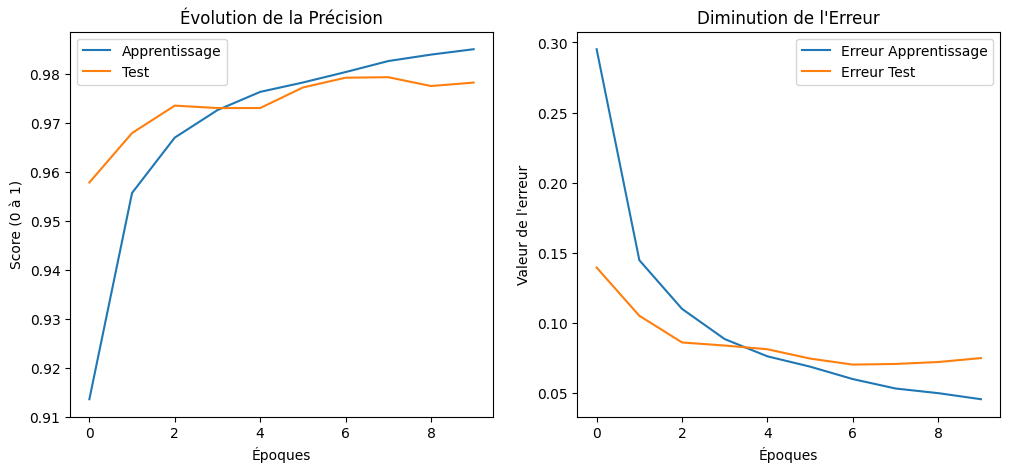

In [ ]:
# On utilise 'history' qui vient d'être généré juste au-dessus
plt.figure(figsize=(12, 5)) # Crée une fenêtre de 12x5 pouces

# Graphique de la Précision (Accuracy)
plt.subplot(1, 2, 1) # Divise la fenêtre en 1 ligne, 2 colonnes, et choisit la 1ère place
plt.plot(history.history['accuracy'], label='Apprentissage') # Ligne de précision sur train
plt.plot(history.history['val_accuracy'], label='Test') # Ligne de précision sur test
plt.title('Évolution de la Précision') # Titre du premier graphe
plt.xlabel('Époques') # Nom de l'axe X
plt.ylabel('Score (0 à 1)') # Nom de l'axe Y
plt.legend() # Affiche les noms des lignes

# Graphique de l'Erreur (Loss)
plt.subplot(1, 2, 2) # Choisit la 2ème place dans la fenêtre
plt.plot(history.history['loss'], label='Erreur Apprentissage') # Ligne d'erreur sur train
plt.plot(history.history['val_loss'], label='Erreur Test') # Ligne d'erreur sur test
plt.title('Diminution de l\'Erreur') # Titre du second graphe
plt.xlabel('Époques') # Nom de l'axe X
plt.ylabel('Valeur de l\'erreur') # Nom de l'axe Y
plt.legend() # Affiche les noms des lignes

plt.show() # Affiche l'ensemble des graphiques

ÉTAPE 6 : TEST FINAL SUR UNE IMAGE

In [ ]:
# On demande au modèle d'évaluer sa précision finale sur tout le set de test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\n Score final de précision : {accuracy*100:.2f}%")


 Score final de précision : 97.82%
